In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [3]:
fund_master = pd.read_csv("data/raw/01_fund_master.csv")

nav = pd.read_csv("data/processed/02_nav_history_cleaned.csv")

benchmark = pd.read_csv("data/raw/10_benchmark_indices.csv")

scheme = pd.read_csv("data/processed/07_scheme_performance_cleaned.csv")

print("Fund Master :", fund_master.shape)
print("NAV History :", nav.shape)
print("Benchmark :", benchmark.shape)
print("Scheme Performance :", scheme.shape)

Fund Master : (40, 15)
NAV History : (46000, 3)
Benchmark : (8050, 3)
Scheme Performance : (40, 19)


In [4]:
print(nav.head())

print(nav.info())

print(nav.describe())

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB
None
           amfi_code           nav
count   46000.000000  46000.000000
mean   120247.000000    269.570265
std     14352.317221    577.187060
min    100016.000000     26.136600
25%    118632.750000     69.170425
50%    119551.500000    122.732150
75%    120842.250000    260.338675
max    149324.000000   4268.549700


In [5]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

In [6]:
nav["daily_return"] = (

    nav
    .groupby("amfi_code")["nav"]
    .pct_change()

)

print(nav.head(10))

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073


In [7]:
print(nav["daily_return"].describe())

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


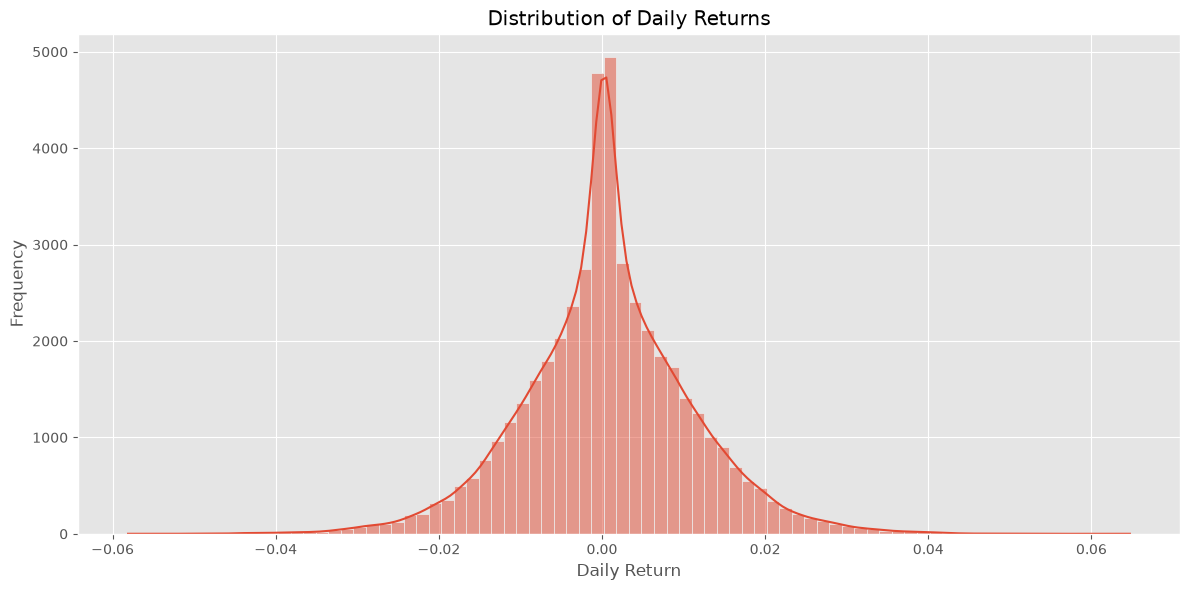

In [8]:
# DAILY RETURN DISTRIBUTION
plt.figure(figsize=(12,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=80,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("reports/charts/daily_return_distribution.png")

plt.show()

In this section, we prepared our environment for Mutual Fund Performance Analytics and completed the first and most important calculation—Daily Returns. We began by importing the required Python libraries such as Pandas for data manipulation, NumPy for numerical calculations, Matplotlib, Seaborn, and Plotly for visualizations, and SciPy for statistical analysis that will be used later for Alpha and Beta calculations. After that, we loaded the required datasets, including the fund master data, cleaned NAV history, benchmark indices, and scheme performance data, which will be used throughout the analysis.

Next, we converted the date column into the proper datetime format and sorted the NAV data by AMFI code and date. Sorting is essential because financial calculations must follow the correct chronological order. We then calculated the Daily Return for each mutual fund using the formula (Today's NAV / Previous Day's NAV) − 1. Instead of manually applying this formula, we used Pandas' groupby() and pct_change() functions, which automatically compute percentage changes separately for each fund. This ensures that returns are calculated only within the same scheme and not across different funds.

Finally, we analyzed the distribution of daily returns by displaying summary statistics and plotting a histogram. This validation step helps verify that the calculated returns are realistic and follow a normal market behavior, where most daily returns are close to zero with fewer large positive or negative movements. This Daily Return dataset forms the foundation for all the advanced financial metrics we will calculate next, including CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, Maximum Drawdown, Tracking Error, and the overall Fund Scorecard. Without accurately computing daily returns, none of the subsequent performance analyses would be reliable.

In [9]:
# CAGR FUNCTION
def calculate_cagr(start_nav, end_nav, years):

    return ((end_nav / start_nav) ** (1 / years) - 1) * 100

In [10]:
cagr_results = []

In [14]:
# CAGR CALCULATION
for amfi_code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    latest_date = group["date"].max()

    latest_nav = group.iloc[-1]["nav"]

    result = {
        "amfi_code": amfi_code
    }

    for years in [1, 3, 5]:

        start_date = latest_date - pd.DateOffset(years=years)

        temp = group[group["date"] >= start_date]

        if len(temp) > 0:

            start_nav = temp.iloc[0]["nav"]

            result[f"CAGR_{years}Y"] = calculate_cagr(
                start_nav,
                latest_nav,
                years
            )

        else:

            result[f"CAGR_{years}Y"] = np.nan

    cagr_results.append(result)
print(cagr_results)

[{'amfi_code': 100016, 'CAGR_1Y': np.float64(-2.224270997710287), 'CAGR_3Y': np.float64(1.292649342495622), 'CAGR_5Y': np.float64(2.3168434686413164)}, {'amfi_code': 100025, 'CAGR_1Y': np.float64(3.704968580461343), 'CAGR_3Y': np.float64(3.9163899571040384), 'CAGR_5Y': np.float64(3.912652604315703)}, {'amfi_code': 100033, 'CAGR_1Y': np.float64(53.23239623092084), 'CAGR_3Y': np.float64(32.442459421956116), 'CAGR_5Y': np.float64(26.0740682788986)}, {'amfi_code': 101206, 'CAGR_1Y': np.float64(47.92412023860102), 'CAGR_3Y': np.float64(28.96769452874166), 'CAGR_5Y': np.float64(20.442729550832482)}, {'amfi_code': 101207, 'CAGR_1Y': np.float64(-23.986031710270627), 'CAGR_3Y': np.float64(-4.152381044854481), 'CAGR_5Y': np.float64(6.953335702239261)}, {'amfi_code': 101208, 'CAGR_1Y': np.float64(7.23664530138024), 'CAGR_3Y': np.float64(6.315784491375509), 'CAGR_5Y': np.float64(5.705734207350055)}, {'amfi_code': 102885, 'CAGR_1Y': np.float64(20.207703983094838), 'CAGR_3Y': np.float64(19.667262068

In [17]:
cagr_df = pd.DataFrame(cagr_results)
cagr_df = cagr_df.merge(

    fund_master[
        ["amfi_code", "scheme_name", "fund_house"]
    ],

    on="amfi_code",

    how="left"

)
print(cagr_df.head())

print(cagr_df.describe())

   amfi_code    CAGR_1Y    CAGR_3Y    CAGR_5Y                                        scheme_name                fund_house
0     100016  -2.224271   1.292649   2.316843          HDFC Top 100 Fund - Regular Plan - Growth          HDFC Mutual Fund
1     100025   3.704969   3.916390   3.912653       HDFC Short Term Debt Fund - Regular - Growth          HDFC Mutual Fund
2     100033  53.232396  32.442459  26.074068  HDFC Mid-Cap Opportunities Fund - Regular - Gr...          HDFC Mutual Fund
3     101206  47.924120  28.967695  20.442730      ABSL Frontline Equity Fund - Regular - Growth  Aditya Birla Sun Life MF
4     101207 -23.986032  -4.152381   6.953336             ABSL Small Cap Fund - Regular - Growth  Aditya Birla Sun Life MF
           amfi_code     CAGR_1Y     CAGR_3Y     CAGR_5Y
count     160.000000  160.000000  160.000000  160.000000
mean   120247.000000   19.428520   16.414715   14.541077
std     14397.223059   22.695093   12.091046    8.817465
min    100016.000000  -42.797615  

In [18]:
cagr_df = cagr_df.sort_values(

    by="CAGR_3Y",

    ascending=False

)

print(cagr_df.head(10))

     amfi_code    CAGR_1Y    CAGR_3Y    CAGR_5Y                                    scheme_name           fund_house
16      119094  22.261065  35.111802  24.445309            Axis Midcap Fund - Regular - Growth     Axis Mutual Fund
136     119094  22.261065  35.111802  24.445309            Axis Midcap Fund - Regular - Growth     Axis Mutual Fund
96      119094  22.261065  35.111802  24.445309            Axis Midcap Fund - Regular - Growth     Axis Mutual Fund
56      119094  22.261065  35.111802  24.445309            Axis Midcap Fund - Regular - Growth     Axis Mutual Fund
34      148567  20.360678  34.000916  26.799277  Mirae Asset Large Cap Fund - Regular - Growth       Mirae Asset MF
74      148567  20.360678  34.000916  26.799277  Mirae Asset Large Cap Fund - Regular - Growth       Mirae Asset MF
154     148567  20.360678  34.000916  26.799277  Mirae Asset Large Cap Fund - Regular - Growth       Mirae Asset MF
114     148567  20.360678  34.000916  26.799277  Mirae Asset Large Cap F

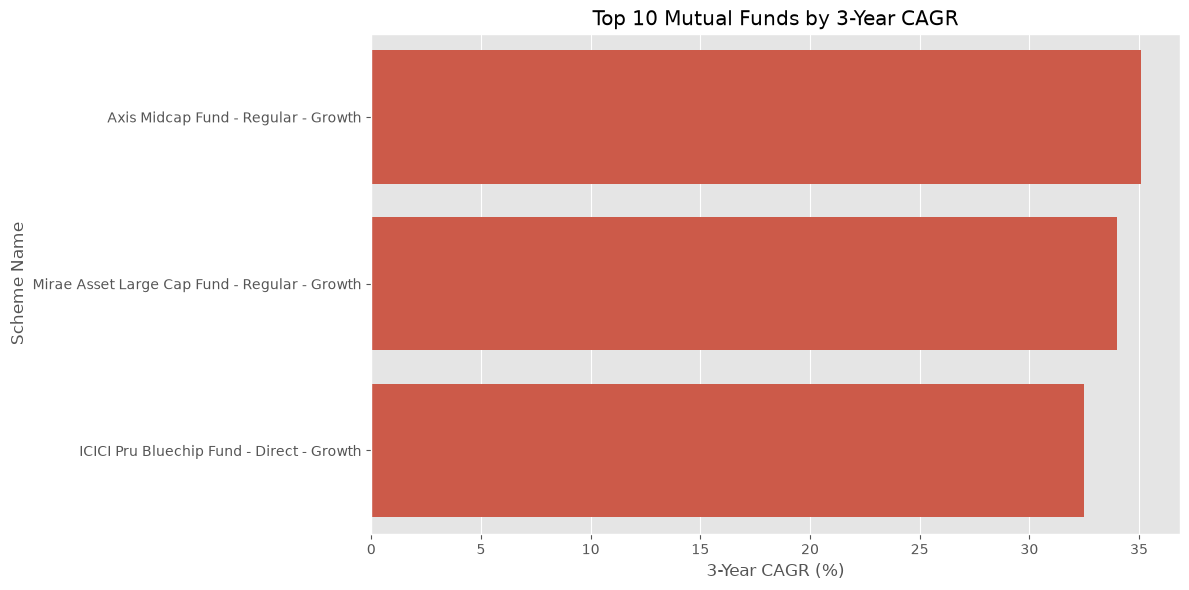

In [21]:
# TOP 10 FUNDS BY 3-YEAR CAGR
plt.figure(figsize=(12,6))

sns.barplot(

    data=cagr_df.head(10),

    x="CAGR_3Y",

    y="scheme_name"

)

plt.title("Top 10 Mutual Funds by 3-Year CAGR")

plt.xlabel("3-Year CAGR (%)")

plt.ylabel("Scheme Name")

plt.tight_layout()

plt.savefig("reports/charts/top10_cagr_3y.png")

plt.show()

In [22]:
cagr_df.to_csv(

    "reports/cagr_table.csv",

    index=False

)

We calculated the Compound Annual Growth Rate (CAGR) for 1-year, 3-year, and 5-year periods for every mutual fund scheme. We created a reusable function to apply the CAGR formula, processed each scheme individually, generated a comparison table, ranked funds based on their 3-Year CAGR, visualized the Top 10 performing funds, and exported the results as a CSV. This gives us a standardized way to compare long-term fund performance and provides one of the key inputs for the Fund Scorecard that we'll build later.

In [24]:
# SHARPE RATIO CALCULATION
# Rf = 6.5% annual (RBI repo rate proxy)
# Sharpe = (Rp - Rf) / Std(Rp) × √252

rf_annual = 0.065
rf_daily = rf_annual / 252  # Convert to daily

sharpe_results = []

for amfi_code, group in nav.groupby("amfi_code"):
    daily_returns = group["daily_return"].dropna()
    
    if len(daily_returns) > 0:
        excess_returns = daily_returns - rf_daily
        sharpe_ratio = (excess_returns.mean() / excess_returns.std()) * np.sqrt(252)
        
        sharpe_results.append({
            "amfi_code": amfi_code,
            "Sharpe_Ratio": sharpe_ratio,
            "Annual_Return": daily_returns.mean() * 252 * 100,
            "Annual_Std": daily_returns.std() * np.sqrt(252) * 100
        })

sharpe_df = pd.DataFrame(sharpe_results)
sharpe_df = sharpe_df.merge(fund_master[["amfi_code", "scheme_name", "fund_house"]], on="amfi_code", how="left")

print("Top 10 Funds by Sharpe Ratio:")
print(sharpe_df.nlargest(10, "Sharpe_Ratio")[["scheme_name", "Sharpe_Ratio", "Annual_Return", "Annual_Std"]])

Top 10 Funds by Sharpe Ratio:
                                          scheme_name  Sharpe_Ratio  Annual_Return  Annual_Std
34      Mirae Asset Large Cap Fund - Regular - Growth      1.448291      27.056620   14.193707
30             Kotak Flexicap Fund - Regular - Growth      1.306744      27.260224   15.886987
36      Mirae Asset Tax Saver Fund - Regular - Growth      1.234930      28.326162   17.674007
19          SBI Bluechip Fund - Regular Plan - Growth      1.208267      23.103315   13.741434
25           ICICI Pru Midcap Fund - Regular - Growth      1.180101      29.265272   19.290949
38                 DSP Midcap Fund - Regular - Growth      1.132122      26.590815   17.746159
2   HDFC Mid-Cap Opportunities Fund - Regular - Gr...      1.093699      27.211057   18.936711
9      Nippon India Large Cap Fund - Regular - Growth      1.081659      21.803695   14.148352
3       ABSL Frontline Equity Fund - Regular - Growth      1.027213      21.464662   14.568213
24          ICICI Pr

In [25]:
# SORTINO RATIO CALCULATION
# Uses only downside standard deviation (negative returns)

sortino_results = []

for amfi_code, group in nav.groupby("amfi_code"):
    daily_returns = group["daily_return"].dropna()
    
    if len(daily_returns) > 0:
        excess_returns = daily_returns - rf_daily
        downside_returns = excess_returns[excess_returns < 0]
        
        if len(downside_returns) > 0:
            downside_std = downside_returns.std()
            sortino_ratio = (excess_returns.mean() / downside_std) * np.sqrt(252)
        else:
            sortino_ratio = np.inf
        
        sortino_results.append({
            "amfi_code": amfi_code,
            "Sortino_Ratio": sortino_ratio,
            "Downside_Std_Ann": downside_std * np.sqrt(252) * 100 if len(downside_returns) > 0 else 0
        })

sortino_df = pd.DataFrame(sortino_results)
sortino_df = sortino_df.merge(fund_master[["amfi_code", "scheme_name"]], on="amfi_code", how="left")

print("Top 10 Funds by Sortino Ratio:")
print(sortino_df.nlargest(10, "Sortino_Ratio")[["scheme_name", "Sortino_Ratio", "Downside_Std_Ann"]])

Top 10 Funds by Sortino Ratio:
                                          scheme_name  Sortino_Ratio  Downside_Std_Ann
34      Mirae Asset Large Cap Fund - Regular - Growth       2.368342          8.679752
30             Kotak Flexicap Fund - Regular - Growth       2.352942          8.823090
36      Mirae Asset Tax Saver Fund - Regular - Growth       2.135083         10.222630
19          SBI Bluechip Fund - Regular Plan - Growth       2.103952          7.891491
25           ICICI Pru Midcap Fund - Regular - Growth       2.010035         11.325808
38                 DSP Midcap Fund - Regular - Growth       1.868935         10.749871
9      Nippon India Large Cap Fund - Regular - Growth       1.839859          8.317863
2   HDFC Mid-Cap Opportunities Fund - Regular - Gr...       1.823824         11.355841
3       ABSL Frontline Equity Fund - Regular - Growth       1.785592          8.380783
24          ICICI Pru Bluechip Fund - Direct - Growth       1.785043          8.260176


In [26]:
# ALPHA AND BETA CALCULATION
# OLS regression: Fund_return = alpha + beta * Benchmark_return
# Using Nifty 100 as benchmark

benchmark["date"] = pd.to_datetime(benchmark["date"])
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()
nifty100 = nifty100.sort_values("date")
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

alpha_beta_results = []

for amfi_code, fund_group in nav.groupby("amfi_code"):
    fund_group = fund_group.sort_values("date").copy()
    
    # Merge fund returns with benchmark returns on date
    merged = fund_group[["date", "daily_return"]].merge(
        nifty100[["date", "benchmark_return"]], 
        on="date", 
        how="inner"
    )
    
    if len(merged) > 252:  # At least 1 year of data
        fund_returns = merged["daily_return"].values
        benchmark_returns = merged["benchmark_return"].values
        
        # Remove NaN values
        valid_idx = ~(np.isnan(fund_returns) | np.isnan(benchmark_returns))
        fund_returns = fund_returns[valid_idx]
        benchmark_returns = benchmark_returns[valid_idx]
        
        if len(fund_returns) > 1:
            slope, intercept, r_value, p_value, std_err = linregress(benchmark_returns, fund_returns)
            
            alpha_annual = intercept * 252
            beta = slope
            
            alpha_beta_results.append({
                "amfi_code": amfi_code,
                "Alpha_Annual": alpha_annual * 100,
                "Beta": beta,
                "R_Squared": r_value ** 2,
                "N_Observations": len(fund_returns)
            })

alpha_beta_df = pd.DataFrame(alpha_beta_results)
alpha_beta_df = alpha_beta_df.merge(fund_master[["amfi_code", "scheme_name", "fund_house"]], on="amfi_code", how="left")

print("Alpha & Beta Analysis (Top 10 by Alpha):")
print(alpha_beta_df.nlargest(10, "Alpha_Annual")[["scheme_name", "Alpha_Annual", "Beta", "R_Squared"]])
print(f"\nTotal funds analyzed: {len(alpha_beta_df)}")

Alpha & Beta Analysis (Top 10 by Alpha):
                                          scheme_name  Alpha_Annual      Beta     R_Squared
21         SBI Small Cap Fund - Regular Plan - Growth     30.336965 -0.023196  1.414258e-04
39              DSP Small Cap Fund - Regular - Growth     30.057878  0.011455  3.532991e-05
25           ICICI Pru Midcap Fund - Regular - Growth     29.263583  0.000549  1.345534e-07
36      Mirae Asset Tax Saver Fund - Regular - Growth     28.270368  0.018134  1.748889e-04
30             Kotak Flexicap Fund - Regular - Growth     27.330465 -0.022830  3.430543e-04
2   HDFC Mid-Cap Opportunities Fund - Regular - Gr...     27.195355  0.005104  1.206652e-05
34      Mirae Asset Large Cap Fund - Regular - Growth     26.983751  0.023684  4.625437e-04
38                 DSP Midcap Fund - Regular - Growth     26.598578 -0.002523  3.357978e-06
16                Axis Midcap Fund - Regular - Growth     26.076669 -0.066265  1.936879e-03
19          SBI Bluechip Fund - Regular

In [27]:
# MAXIMUM DRAWDOWN CALCULATION
# MaxDD = min(NAV / running_max - 1) for each fund

max_dd_results = []

for amfi_code, group in nav.groupby("amfi_code"):
    group = group.sort_values("date").copy()
    
    # Calculate running maximum
    group["running_max"] = group["nav"].expanding().max()
    
    # Calculate drawdown
    group["drawdown"] = (group["nav"] / group["running_max"]) - 1
    
    max_drawdown = group["drawdown"].min()
    max_drawdown_date = group.loc[group["drawdown"].idxmin(), "date"]
    
    # Find the peak before the max drawdown
    max_dd_idx = group["drawdown"].idxmin()
    peak_nav = group.loc[:max_dd_idx, "nav"].max()
    peak_date = group[group["nav"] == peak_nav].iloc[0]["date"]
    
    max_dd_results.append({
        "amfi_code": amfi_code,
        "Max_Drawdown_Pct": max_drawdown * 100,
        "Drawdown_Date": max_drawdown_date,
        "Peak_Date": peak_date,
        "Drawdown_Duration_Days": (max_drawdown_date - peak_date).days
    })

max_dd_df = pd.DataFrame(max_dd_results)
max_dd_df = max_dd_df.merge(fund_master[["amfi_code", "scheme_name", "fund_house"]], on="amfi_code", how="left")

print("Top 10 Funds by Maximum Drawdown (Best):")
print(max_dd_df.nlargest(10, "Max_Drawdown_Pct")[["scheme_name", "Max_Drawdown_Pct", "Peak_Date", "Drawdown_Date", "Drawdown_Duration_Days"]])

Top 10 Funds by Maximum Drawdown (Best):
                                          scheme_name  Max_Drawdown_Pct  Peak_Date Drawdown_Date  Drawdown_Duration_Days
27           ICICI Pru Liquid Fund - Regular - Growth         -0.097731 2025-10-16    2025-10-20                       4
31               Kotak Liquid Fund - Regular - Growth         -0.116293 2024-04-12    2024-04-30                      18
5                 ABSL Liquid Fund - Regular - Growth         -0.162250 2023-09-05    2023-09-12                       7
1        HDFC Short Term Debt Fund - Regular - Growth         -4.308264 2023-05-23    2023-07-28                      66
18       SBI Magnum Gilt Fund - Regular Plan - Growth         -4.328729 2024-09-16    2025-04-01                     197
13  Nippon India Gilt Securities Fund - Regular - ...         -8.316362 2023-02-09    2024-02-09                     365
6          UTI Nifty 50 Index Fund - Regular - Growth        -10.859862 2022-02-03    2022-03-29                

In [28]:
# CONSOLIDATE ALL METRICS FOR FUND SCORECARD
# Merge all metrics: CAGR, Sharpe, Sortino, Alpha, Beta, Max DD, Expense Ratio

# Prepare CAGR data (3-year focus)
cagr_for_scorecard = cagr_df[["amfi_code", "CAGR_3Y"]].copy()

# Prepare Sharpe ratio
sharpe_for_scorecard = sharpe_df[["amfi_code", "Sharpe_Ratio"]].copy()

# Prepare Sortino ratio
sortino_for_scorecard = sortino_df[["amfi_code", "Sortino_Ratio"]].copy()

# Prepare Alpha & Beta
alpha_beta_for_scorecard = alpha_beta_df[["amfi_code", "Alpha_Annual", "Beta"]].copy()

# Prepare Max Drawdown
max_dd_for_scorecard = max_dd_df[["amfi_code", "Max_Drawdown_Pct"]].copy()

# Get expense ratio from fund master
expense_ratio_data = fund_master[["amfi_code", "expense_ratio_pct"]].copy()

# Consolidate
scorecard_base = fund_master[["amfi_code", "scheme_name", "fund_house", "category"]].copy()

scorecard_base = scorecard_base.merge(cagr_for_scorecard, on="amfi_code", how="left")
scorecard_base = scorecard_base.merge(sharpe_for_scorecard, on="amfi_code", how="left")
scorecard_base = scorecard_base.merge(sortino_for_scorecard, on="amfi_code", how="left")
scorecard_base = scorecard_base.merge(alpha_beta_for_scorecard, on="amfi_code", how="left")
scorecard_base = scorecard_base.merge(max_dd_for_scorecard, on="amfi_code", how="left")
scorecard_base = scorecard_base.merge(expense_ratio_data, on="amfi_code", how="left")

print("Consolidated Metrics Shape:", scorecard_base.shape)
print("\nSample of Consolidated Data:")
print(scorecard_base.head())

Consolidated Metrics Shape: (160, 11)

Sample of Consolidated Data:
   amfi_code                                scheme_name       fund_house category    CAGR_3Y  Sharpe_Ratio  Sortino_Ratio  Alpha_Annual      Beta  Max_Drawdown_Pct  expense_ratio_pct
0     119551  SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   Equity  30.456524      1.208267       2.103952     23.201007 -0.031751        -15.012385               1.54
1     119551  SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   Equity  30.456524      1.208267       2.103952     23.201007 -0.031751        -15.012385               1.54
2     119551  SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   Equity  30.456524      1.208267       2.103952     23.201007 -0.031751        -15.012385               1.54
3     119551  SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   Equity  30.456524      1.208267       2.103952     23.201007 -0.031751        -15.012385               1.54
4     119552   SB

In [29]:
# FUND SCORECARD COMPUTATION (0-100 Scale)
# Weighting: 30% 3Y Return + 25% Sharpe + 20% Alpha + 15% Expense Ratio (inverse) + 10% Max DD (inverse)

scorecard = scorecard_base.copy()

# Rank each metric (higher is better, so lower rank = better)
scorecard["CAGR_3Y_Rank"] = scorecard["CAGR_3Y"].rank(method="min", ascending=False)
scorecard["Sharpe_Rank"] = scorecard["Sharpe_Ratio"].rank(method="min", ascending=False)
scorecard["Alpha_Rank"] = scorecard["Alpha_Annual"].rank(method="min", ascending=False)

# For expense ratio, lower is better (inverse ranking)
scorecard["Expense_Rank"] = scorecard["expense_ratio_pct"].rank(method="min", ascending=True)

# For max drawdown, less negative is better (rank inversely - less negative gets higher score)
scorecard["MaxDD_Rank"] = scorecard["Max_Drawdown_Pct"].rank(method="min", ascending=True)

# Get total number of funds for normalization
n_funds = len(scorecard)

# Normalize ranks to 0-100 scale
scorecard["CAGR_3Y_Score"] = (1 - scorecard["CAGR_3Y_Rank"] / n_funds) * 100
scorecard["Sharpe_Score"] = (1 - scorecard["Sharpe_Rank"] / n_funds) * 100
scorecard["Alpha_Score"] = (1 - scorecard["Alpha_Rank"] / n_funds) * 100
scorecard["Expense_Score"] = (1 - scorecard["Expense_Rank"] / n_funds) * 100
scorecard["MaxDD_Score"] = (1 - scorecard["MaxDD_Rank"] / n_funds) * 100

# Compute composite scorecard (0-100)
scorecard["Fund_Scorecard"] = (
    0.30 * scorecard["CAGR_3Y_Score"] +
    0.25 * scorecard["Sharpe_Score"] +
    0.20 * scorecard["Alpha_Score"] +
    0.15 * scorecard["Expense_Score"] +
    0.10 * scorecard["MaxDD_Score"]
)

# Sort by scorecard
scorecard_sorted = scorecard.sort_values("Fund_Scorecard", ascending=False)

print("TOP 15 FUNDS BY COMPOSITE SCORECARD:")
print(scorecard_sorted[["scheme_name", "fund_house", "category", "Fund_Scorecard", "CAGR_3Y", "Sharpe_Ratio", "Alpha_Annual", "expense_ratio_pct", "Max_Drawdown_Pct"]].head(15).to_string())

# Save scorecard to CSV
scorecard_export = scorecard_sorted[["amfi_code", "scheme_name", "fund_house", "category", "Fund_Scorecard", 
                                      "CAGR_3Y", "Sharpe_Ratio", "Sortino_Ratio", "Alpha_Annual", "Beta", 
                                      "Max_Drawdown_Pct", "expense_ratio_pct"]]
scorecard_export.to_csv("reports/fund_scorecard.csv", index=False)
print("\n✓ Fund Scorecard saved to reports/fund_scorecard.csv")

TOP 15 FUNDS BY COMPOSITE SCORECARD:
                                            scheme_name           fund_house category  Fund_Scorecard    CAGR_3Y  Sharpe_Ratio  Alpha_Annual  expense_ratio_pct  Max_Drawdown_Pct
48             ICICI Pru Midcap Fund - Regular - Growth  ICICI Prudential MF   Equity          83.875  31.777537      1.180101     29.263583               1.36        -18.188514
49             ICICI Pru Midcap Fund - Regular - Growth  ICICI Prudential MF   Equity          83.875  31.777537      1.180101     29.263583               1.36        -18.188514
50             ICICI Pru Midcap Fund - Regular - Growth  ICICI Prudential MF   Equity          83.875  31.777537      1.180101     29.263583               1.36        -18.188514
51             ICICI Pru Midcap Fund - Regular - Growth  ICICI Prudential MF   Equity          83.875  31.777537      1.180101     29.263583               1.36        -18.188514
107                 Axis Midcap Fund - Regular - Growth     Axis Mutual F

In [30]:
# ALPHA & BETA CSV EXPORT

alpha_beta_export = alpha_beta_df[["amfi_code", "scheme_name", "fund_house", "Alpha_Annual", "Beta", "R_Squared", "N_Observations"]].copy()
alpha_beta_export = alpha_beta_export.sort_values("Alpha_Annual", ascending=False)
alpha_beta_export.to_csv("reports/alpha_beta.csv", index=False)
print("✓ Alpha & Beta analysis saved to reports/alpha_beta.csv")
print("\nTop 10 Funds by Alpha:")
print(alpha_beta_export.head(10).to_string())

✓ Alpha & Beta analysis saved to reports/alpha_beta.csv

Top 10 Funds by Alpha:
    amfi_code                                         scheme_name           fund_house  Alpha_Annual      Beta     R_Squared  N_Observations
21     119598          SBI Small Cap Fund - Regular Plan - Growth      SBI Mutual Fund     30.336965 -0.023196  1.414258e-04            1149
39     149324               DSP Small Cap Fund - Regular - Growth      DSP Mutual Fund     30.057878  0.011455  3.532991e-05            1149
25     120505            ICICI Pru Midcap Fund - Regular - Growth  ICICI Prudential MF     29.263583  0.000549  1.345534e-07            1149
36     148569       Mirae Asset Tax Saver Fund - Regular - Growth       Mirae Asset MF     28.270368  0.018134  1.748889e-04            1149
30     120843              Kotak Flexicap Fund - Regular - Growth    Kotak Mahindra MF     27.330465 -0.022830  3.430543e-04            1149
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Growth     HDFC

In [32]:
# BENCHMARK COMPARISON & TRACKING ERROR
# Get top 5 funds by Fund Scorecard
top_5_funds = scorecard_sorted.head(5)["amfi_code"].values

# Get Nifty 50 and Nifty 100 data
nifty50 = benchmark[benchmark["index_name"] == "NIFTY50"].copy()
nifty50 = nifty50.sort_values("date")
nifty50["benchmark_return"] = nifty50["close_value"].pct_change()
nifty50 = nifty50[["date", "close_value", "benchmark_return"]].rename(columns={"close_value": "NIFTY50", "benchmark_return": "nifty50_return"})

nifty100_bench = nifty100[["date", "close_value", "benchmark_return"]].rename(columns={"close_value": "NIFTY100", "benchmark_return": "nifty100_return"})

# Filter to last 3 years
three_years_ago = pd.Timestamp.now() - pd.DateOffset(years=3)

tracking_error_results = []
cumulative_returns = {}

for amfi_code in top_5_funds:
    fund_group = nav[nav["amfi_code"] == amfi_code].sort_values("date").copy()
    fund_group = fund_group[fund_group["date"] >= three_years_ago].copy()
    
    # Merge with benchmarks
    fund_group = fund_group[["date", "nav", "daily_return"]].merge(nifty50, on="date", how="inner")
    fund_group = fund_group.merge(nifty100_bench, on="date", how="inner")
    
    if len(fund_group) > 0:
        # Tracking error vs Nifty 100 (primary benchmark)
        tracking_diff = fund_group["daily_return"] - fund_group["nifty100_return"]
        tracking_error = tracking_diff.std() * np.sqrt(252)
        
        # Cumulative return calculation
        fund_group["fund_cumulative"] = (1 + fund_group["daily_return"]).cumprod()
        fund_group["nifty100_cumulative"] = (1 + fund_group["nifty100_return"]).cumprod()
        fund_group["nifty50_cumulative"] = (1 + fund_group["nifty50_return"]).cumprod()
        
        cumulative_returns[amfi_code] = fund_group[["date", "fund_cumulative", "nifty100_cumulative", "nifty50_cumulative"]].copy()
        
        scheme_name = fund_master[fund_master["amfi_code"] == amfi_code]["scheme_name"].values[0]
        
        tracking_error_results.append({
            "amfi_code": amfi_code,
            "scheme_name": scheme_name,
            "Tracking_Error_Annual": tracking_error * 100,
            "N_Days": len(fund_group)
        })

tracking_error_df = pd.DataFrame(tracking_error_results)
print("Tracking Error (vs Nifty 100) - Top 5 Funds:")
print(tracking_error_df.to_string())

Tracking Error (vs Nifty 100) - Top 5 Funds:
   amfi_code                               scheme_name  Tracking_Error_Annual  N_Days
0     120505  ICICI Pru Midcap Fund - Regular - Growth              23.229686     762
1     120505  ICICI Pru Midcap Fund - Regular - Growth              23.229686     762
2     120505  ICICI Pru Midcap Fund - Regular - Growth              23.229686     762
3     120505  ICICI Pru Midcap Fund - Regular - Growth              23.229686     762
4     119094       Axis Midcap Fund - Regular - Growth              24.092916     762


✓ Benchmark comparison chart saved to reports/charts/benchmark_comparison_top5.png


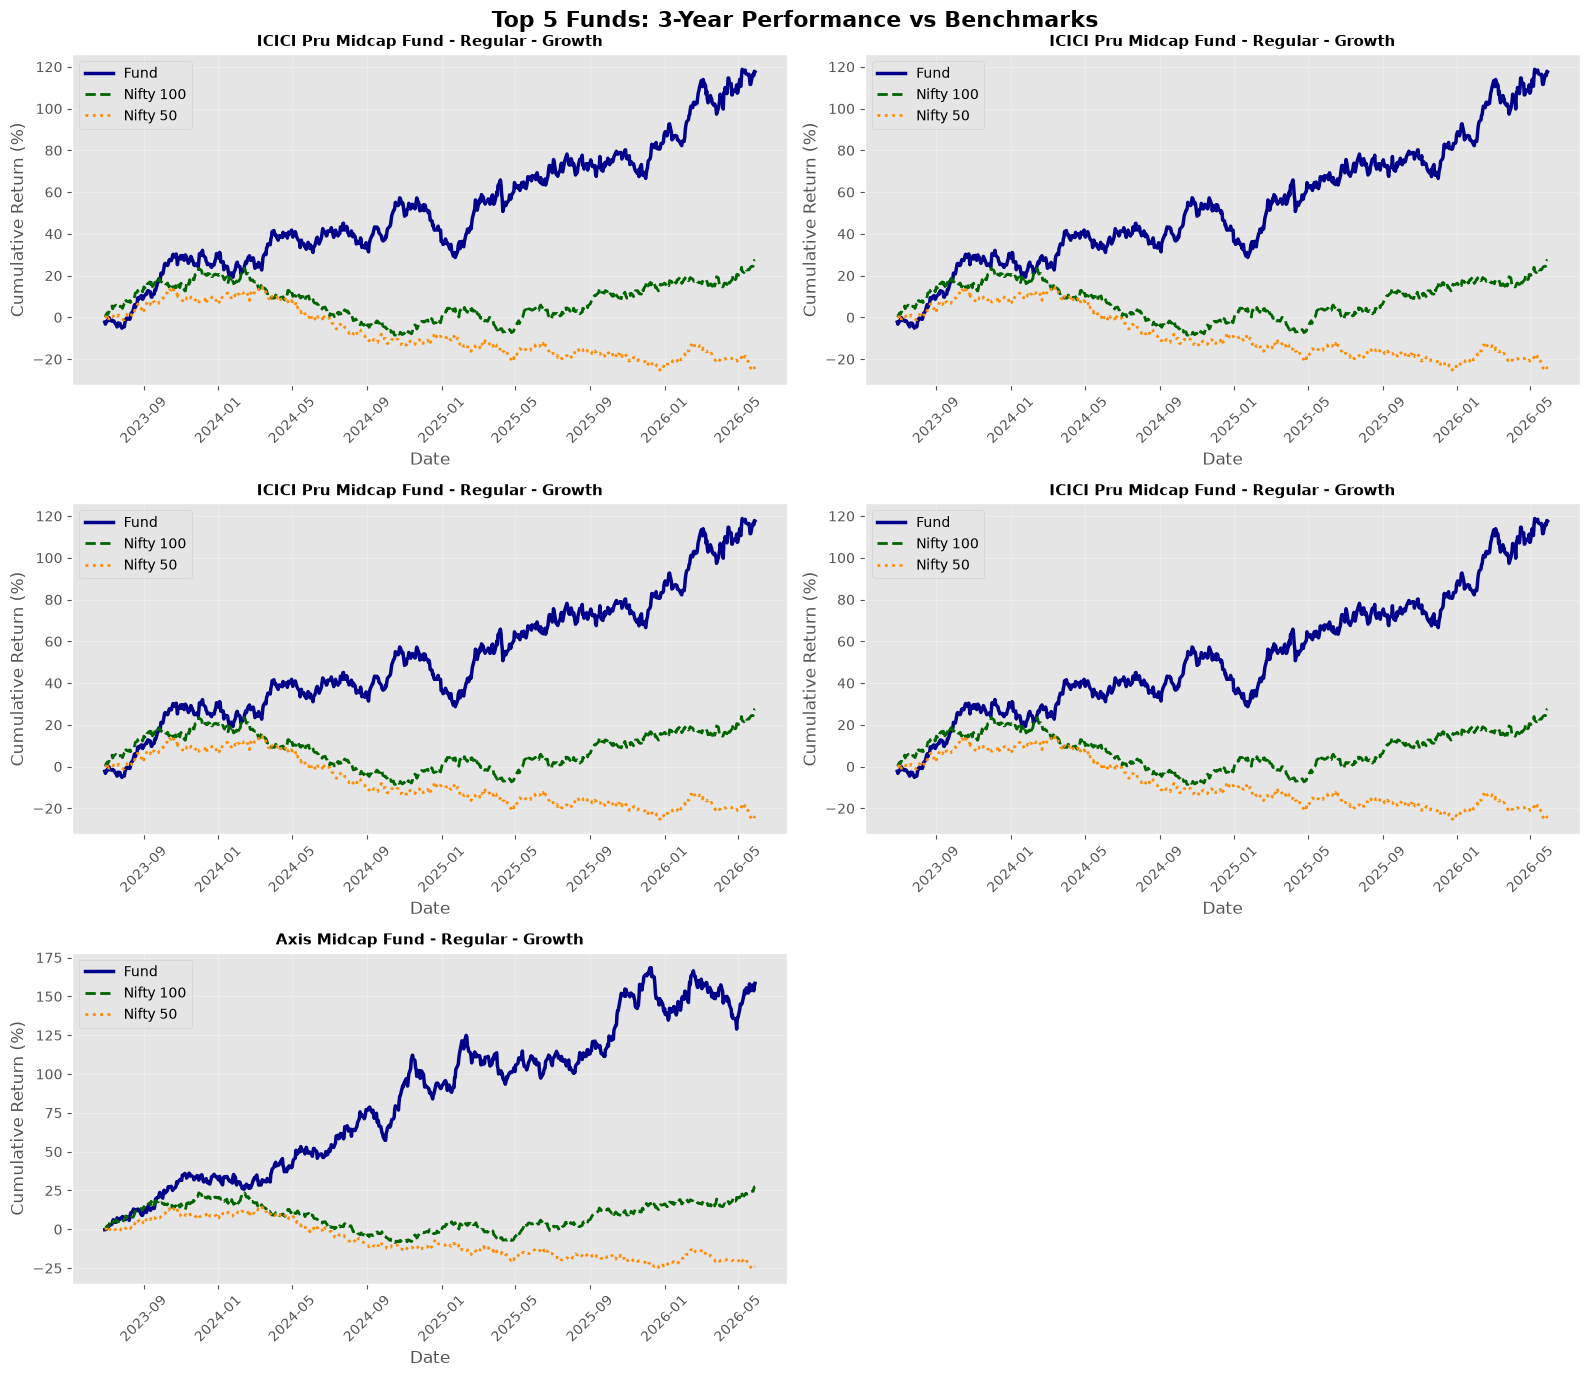

In [33]:
# BENCHMARK COMPARISON CHART - Top 5 Funds vs Nifty 50 & Nifty 100
# Create comprehensive visualization

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle("Top 5 Funds: 3-Year Performance vs Benchmarks", fontsize=16, fontweight="bold")

for idx, amfi_code in enumerate(top_5_funds):
    if amfi_code in cumulative_returns:
        data = cumulative_returns[amfi_code]
        scheme_name = fund_master[fund_master["amfi_code"] == amfi_code]["scheme_name"].values[0]
        
        ax = axes[idx // 2, idx % 2]
        
        # Plot cumulative returns
        ax.plot(data["date"], (data["fund_cumulative"] - 1) * 100, label="Fund", linewidth=2.5, color="darkblue")
        ax.plot(data["date"], (data["nifty100_cumulative"] - 1) * 100, label="Nifty 100", linewidth=2, linestyle="--", color="darkgreen")
        ax.plot(data["date"], (data["nifty50_cumulative"] - 1) * 100, label="Nifty 50", linewidth=2, linestyle=":", color="darkorange")
        
        ax.set_title(f"{scheme_name}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Date")
        ax.set_ylabel("Cumulative Return (%)")
        ax.legend(loc="best")
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis="x", rotation=45)

# Remove extra subplot
axes[2, 1].remove()

plt.tight_layout()
plt.savefig("reports/charts/benchmark_comparison_top5.png", dpi=300, bbox_inches="tight")
print("✓ Benchmark comparison chart saved to reports/charts/benchmark_comparison_top5.png")
plt.show()